# Introducing Ensemble Spatial Simulation (ESS)
<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

## The Spatial Simulation Challenge

Estimates from [**Ensemble Spatial Interpolation (ESI)**](./esi_overview.ipynb) and its locally-adaptive variant **Adaptive Ensemble Spatial Analysis (ESA)** are built by aggregating many per-partition predictions — the **ESI samples** — into a point prediction and a precision score, one location at a time. For many applications, that is not enough. Computing probabilities and other measures of risk requires the **full random field**, expressed as multiple, equally plausible realizations of the entire spatial domain, rather than a single point estimate.

This is the domain of **geostatistical simulation**. Classical approaches such as turning-bands and sequential Gaussian simulation are well established, but they require an explicit variogram model, assume stationarity across the domain, and demand the same geostatistical expertise that motivated ESI in the first place. Being built around reproducing global second-order statistics, they also tend to miss fine-scale features such as the nugget effect unless these are added to the model by hand.

**Ensemble Spatial Simulation (ESS)** is Spatialize's data-driven answer to this problem, introduced by Egaña et al. (2025, AIMS Mathematics) as an application of a more general result, namely that a probability distribution fitted independently at every location, using only that location's own ESI/ESA ensemble, is enough to recover the full joint distribution of the spatial field. ESS builds directly on top of an existing ESI/ESA estimation, requires no variogram modelling, and, as shown below, naturally reproduces the nugget effect directly from the data.

## Introducing ESS

**`ESIResult`**`.esi_samples()` gives direct access to the full per-location ensemble behind each ESI/ESA estimate, one set of values per target location. It might seem safe to treat these ensembles as pure noise, discarded once averaged into the final estimate. In practice, the partitions producing them overlap and reuse observations across nearby locations, so ensembles at nearby locations are not mutually independent. Locations whose partition cells share observations end up with statistically dependent local distributions, a shared structure that behaves like an implicitly learned **spatial copula**, without ever specifying one explicitly.

The practical consequence is that fitting a probability distribution to each location's own ensemble, then sampling from these local distributions *independently, location by location*, still produces a spatially coherent field, because the dependence is already encoded in the shared data that produced each local ensemble in the first place. Informally,

$$
p\big(Z(x_1), \ldots, Z(x_N) \mid \mathcal{O}\big) \;\approx\; \prod_{i=1}^{N} p\big(Z(x_i) \mid \mathcal{N}(x_i)\big),
$$

where $\mathcal{N}(x_i)$ denotes the neighborhood of observations feeding the ensemble at location $x_i$. This factorization is exactly what ESS exploits, turning a hard, global simulation problem into $N$ independent (but not *informationally* independent) local sampling problems.

## The ESS Workflow in Spatialize

Concretely, generating scenarios with ESS involves three steps:

1. **Run ESI or Adaptive ESA** (`esi_griddata` / `esi_nongriddata`) to obtain an **`ESIResult`**. This result carries the full per-location ensemble, not just the aggregated estimate.
2. **Choose a local probability model** for the per-location ensembles, configured through a **`FittedModelFactory`**:
   - `point_model_name="kde"` — Kernel Density Estimation (Gaussian or top-hat kernel). Fastest option; preserves fine-scale texture and is particularly good at capturing the **nugget effect** directly from the data.
   - `point_model_name="emm"` — Gaussian Mixture Model fit via Expectation-Maximization. Produces smoother local distributions, useful when a location's ensemble shows bimodal or multi-population behavior.
   - `point_model_name="vim"` — Gaussian Mixture Model fit via Variational Inference. More robust when the local ensemble is small or sparse, at the cost of extra computation.
3. **Draw scenarios** with `ess_sample(esi_result, n_sims, fitted_model_factory)`, which fits the chosen local model at every target location and draws `n_sims` values from it. The result is an **`ESSResult`** wrapping an ($N_{\text{locations}} \times$ `n_sims`) matrix, where each column is one complete, spatially consistent realization of the field.

## Example: Simulating Scenarios from an ESA Estimation

### Setup
This example uses one of the datasets bundled with Spatialize, which includes 1000 anisotropic Gaussian simulations, of which we keep a single one as ground truth, together with a reduced conditioning sample drawn from it. This mirrors the synthetic case study used in the ESS paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spatialize.data import load_simulated_anisotropic_data
from spatialize.gs.esi import esi_nongriddata
from spatialize.gs.ess import ess_sample
from spatialize.empirical import FittedModelFactory

# the samples included in the spatialize package
_, _, data_reduced, ground_truth = load_simulated_anisotropic_data()

# the 10th simulation (out of 1000) is used as the ground truth for this example
using_sim = 'sim10'

points = data_reduced[0][['x', 'y']].values
values = data_reduced[0][[using_sim]].values[:, 0]
xi = ground_truth[['x', 'y']].values

### Step 1 — Point Estimation with Adaptive ESI

First, we obtain an ESA estimate.

finished 100% of 300 iterations ... 

done (elapsed time: 54s)
finished 100% of 300 iterations ... 

done (elapsed time:  1m  9s)


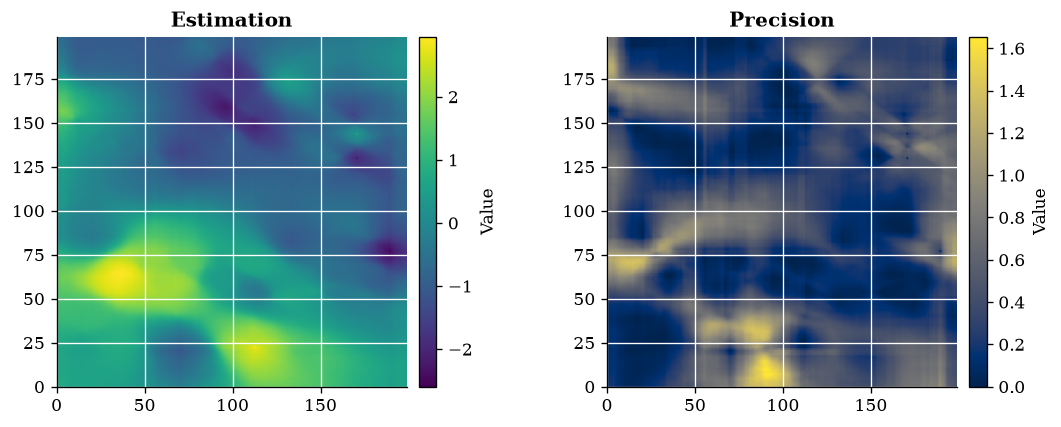

In [2]:
result = esi_nongriddata(points, values, xi,
                         local_interpolator="adaptiveidw",
                         n_partitions=300,
                         alpha=0.7)

result.quick_plot(figsize=(10, 5), theme='publication')
plt.show()

### Step 2 — Simulating Scenarios with KDE

Now we treat the ensemble behind that estimate as a set of local predictive distributions, and sample from them.

::: {.callout-note icon=false}

## Usage Notes

1. `ess_sample` parallelizes per-location fitting across processes via `n_jobs` (`-1` by default). We use `n_jobs=1` here, since multiprocessing needs a `__main__` guard that notebooks can't provide.
2. `FittedModelFactory` takes a `widening` argument (off by default) that corrects ensembles under-representing local variability. See [`empirical_tools.ipynb`](../utilities/empirical_tools.ipynb) for how it works.
:::

finished 100% of 40000 iterations ... 

done (elapsed time:  2m 14s)


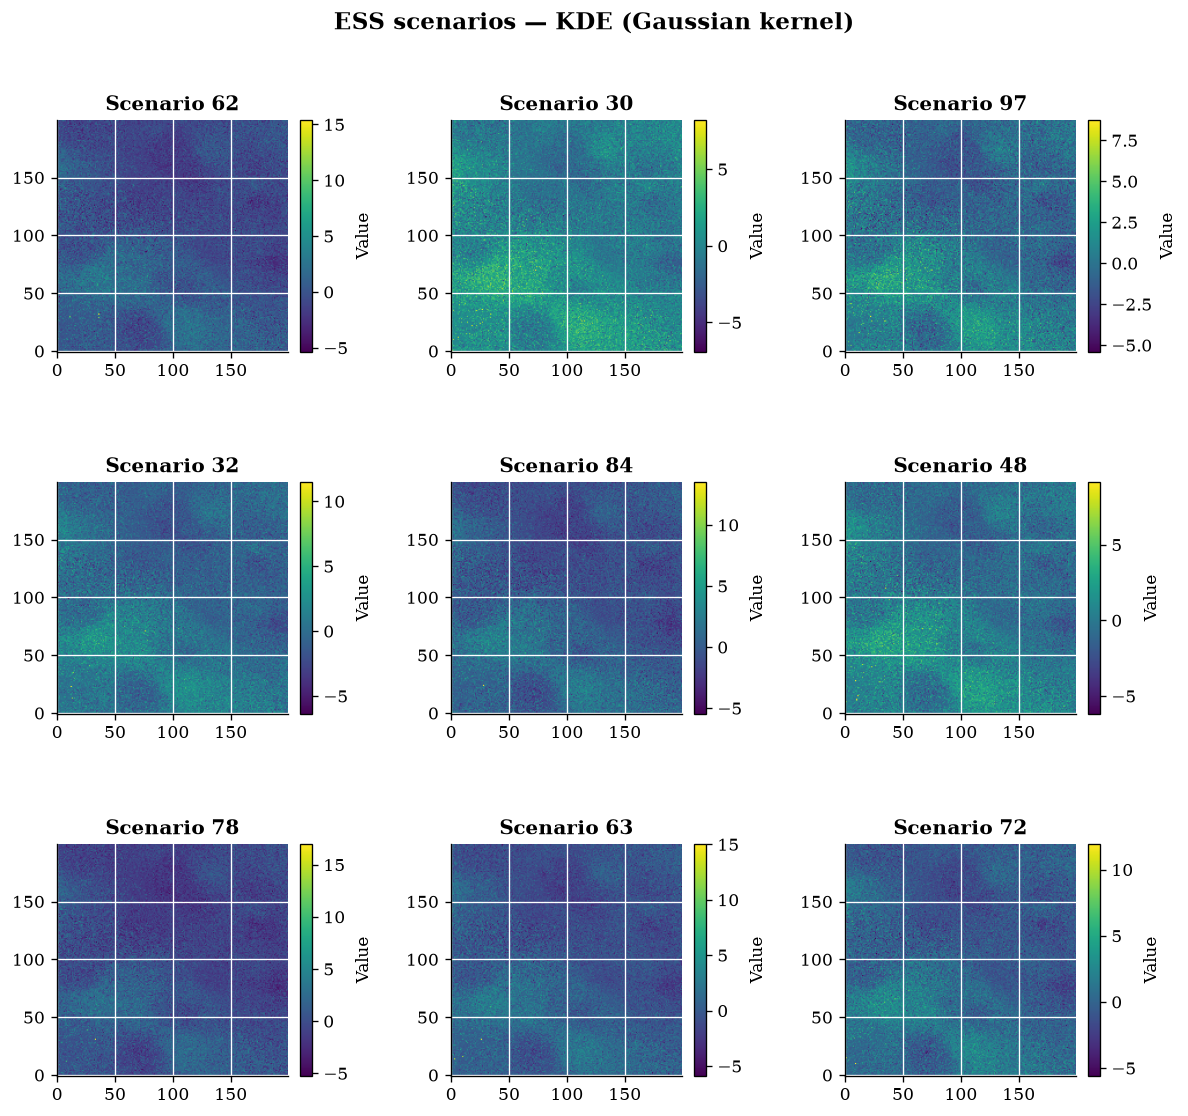

In [3]:
sim_result_kde = ess_sample(esi_result=result,
                            n_sims=100,
                            n_jobs=1,
                            fitted_model_factory=FittedModelFactory(
                                point_model_name="kde",
                                kernel="gaussian",
                                widening='auto',
                                seed=1000
                            ))

# pending: seed for quick plot
sim_result_kde.quick_plot(n_imgs=9, n_cols=3, norm_lims=False,
                          title="ESS scenarios — KDE (Gaussian kernel)",
                          title_prefix="Scenario", theme='publication')
plt.show()

### Step 3 — A Different Local Model: Gaussian Mixtures

Swapping the **`FittedModelFactory`** configuration changes how the local distributions are fit, and therefore the character of the resulting scenarios.

finished 100% of 40000 iterations ... 

done (elapsed time: 13m  6s)


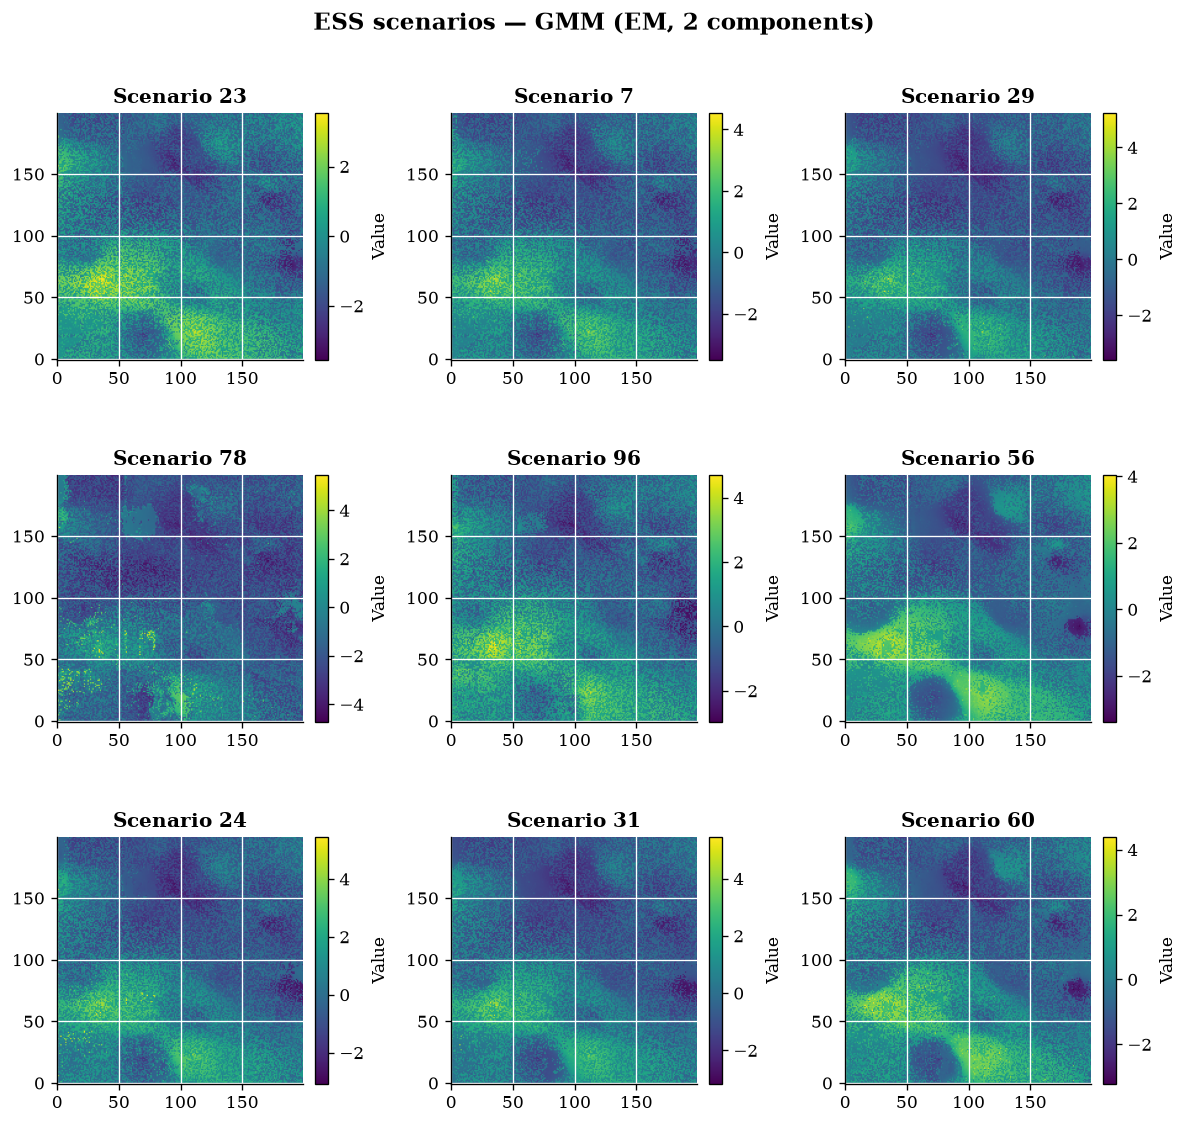

In [4]:
sim_result_gmm = ess_sample(esi_result=result,
                            n_sims=100,
                            n_jobs=1,
                            fitted_model_factory=FittedModelFactory(
                                point_model_name="emm",
                                n_components=2,
                                widening='auto',
                                seed=42
                            ))

sim_result_gmm.quick_plot(n_imgs=9, n_cols=3, norm_lims=False,
                          title="ESS scenarios — GMM (EM, 2 components)",
                          title_prefix="Scenario", 
                          theme='publication')
plt.show()

Each column of `sim_result_kde.scenarios` (or `sim_result_gmm.scenarios`) is one full realization of the field over `xi`. Running the same downstream calculation on every column quantifies its uncertainty.

## Choosing a Local Model

- **KDE** is fastest and preserves fine-scale texture, including the nugget effect, by closely following each ensemble's empirical spread. The Gaussian kernel is a reasonable default; the top-hat kernel suits sudden local changes.
- **GMM (EM)** produces smoother scenarios, useful when a location's ensemble hints at more than one population, though it risks overfitting with too many components or sparse data.
- **GMM (Variational Inference)** behaves like EM but is more robust for small or sparse ensembles, at the cost of extra computation.

There is no single best choice. The right model depends on how much local texture versus smoothness suits the variable being simulated.

## Why the Scenarios Stay Spatially Consistent

ESS does not fit a single global spatial model and draw correlated samples from it, the way turning-bands or sequential Gaussian simulation does. Each location's scenario values come from its own, independently fit local distribution. Spatial coherence survives because those distributions were never truly independent, having been built from the same overlapping observations through the ESI/ESA ensemble, and that shared information reproduces the field's texture and continuity without ever writing down a variogram.

## Further Reading

- **ESI Original**: Egaña, Á.F., Navarro, F., Maleki, M., et al. (2021). *Ensemble Spatial Interpolation: A New Approach to Natural or Anthropogenic Variable Assessment*. Natural Resources Research **30**(5), 3777-3793. https://doi.org/10.1007/s11053-021-09860-2
- **Adaptive ESA**: Egaña, Á.F., Valenzuela, M.J., Maleki, M. et al. (2025). *Adaptive ensemble spatial analysis*. Scientific Reports **15**, 26599. https://doi.org/10.1038/s41598-025-08844-z
- **Spatialize Library**: Navarro, F., Egaña, Á.F., et al. (2025). *Spatialize v1.0: A Python/C++ Library for Ensemble Spatial Interpolation*. arXiv:2507.17867. https://arxiv.org/abs/2507.17867
- **ESS / Spatial Distributional Estimation**: Egaña, Á.F., Díaz, G., Navarro, F., Maleki, M., Sánchez-Pérez, J.F. (2025). *Spatial distributional estimation via ensemble spatial analysis*. AIMS Mathematics **10**(11), 26351-26388. https://doi.org/10.3934/math.20251159